## Lomb-Scargle Analysis Code for TGP Asteroids 2 (2025-26)

In [1]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

In [2]:
# This is hardcoded in, sorry fellas
# Can't use the files off of GitHub, so if you want to run this, download the files in the folder and replace the file paths accordingly, much love

data_file1 = "C:/Users/Matylda/Documents/TGP/Data/data_3ast_4star"
data_file2 = "C:/Users/Matylda/Documents/TGP/Data/data_5ast_5star"

### Inspect the data files (here, just 3 pix asteroid, 4 pix standard stars - scroll down for the second file)

In [3]:
def read_data(file_path):

    # Read the data file in
    data = np.loadtxt(data_file1, skiprows=1, delimiter="|")

    # Extract data
    times = data[:, 0] # This is in hours 
    magnitudes = data[:, 1]  
    mag_errors = data[:, 2]  

    # Need to convert to days
    times_days = times / 24.0


    plt.figure(figsize=(12, 4))
    plt.errorbar(times, magnitudes, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='black')
    plt.xlabel('Time (hours)')
    plt.ylabel('Relative Magnitude')
    plt.gca().invert_yaxis()
    plt.title('Light Curve')
    plt.show()

    return times, times_days, magnitudes, mag_errors

### Now, let's actually get the lightcurve period

In [112]:
def lomb_scargle(times, times_days, mags, mag_errors):

    ls = LombScargle(times_days, mags, mag_errors)

    frequency, power = ls.autopower(minimum_frequency=1.0,
                                    maximum_frequency=24.0, 
                                    samples_per_peak=10)

    # Find the best period
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency

    print(f"Best period: {best_period:.4f} days ({best_period*24:.2f} hours)")
    print(f"Peak power: {power.max():.4f}")

    # Find the FWHM of the peak for an alternative uncertainty estimation 
    peak_power = power.max()
    peak_idx = np.argmax(power)
    half_max = peak_power / 2

    # Find frequencies where power drops to half maximum
    left_idx = peak_idx
    while left_idx > 0 and power[left_idx] > half_max:
        left_idx -= 1

    right_idx = peak_idx
    while right_idx < len(power) - 1 and power[right_idx] > half_max:
        right_idx += 1

    freq_width = frequency[right_idx] - frequency[left_idx]
    period_uncertainty_fwhm = freq_width / (best_frequency**2)

    print(f"Period uncertainty using FWHM: +/- {period_uncertainty_fwhm:.4f} days ( +/-{period_uncertainty_fwhm*24:.2f} hours)")
    print(f"Period: {best_period*24:.2f} +/- {period_uncertainty_fwhm*24:.2f} hours")
    # Calculate false alarm probability
    false = ls.false_alarm_probability(power.max())
    print(f"False alarm probability: {false:.4e}")

    #Periodogram
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

    period_hours = (1/frequency) * 24  # Convert to hours
    ax1.plot(period_hours, power, color='black')
    ax1.set_xlabel('Period (hours)')
    ax1.set_ylabel('Power')
    ax1.axvline(best_period * 24, color='red', linestyle='--', 
                label=f'Best period: {best_period*24:.2f} hours')
    ax1.legend()
    ax1.set_xlim(1, 24)  # Focus on reasonable asteroid periods

    phase = (times_days % best_period) / best_period
    phase2 = (times_days % (2*best_period)) / (2*best_period)
    sorted_idx = np.argsort(phase)
    
    t_fit = np.linspace(0, best_period, 1000)
    phase_fit = (t_fit) / best_period
    phase2_fit = (t_fit) / (2*best_period)

    y = ls.model(t_fit, best_frequency)
    ax2.plot(phase_fit, y, color='black')
    ax2.errorbar(phase, mags, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='blue')
    #ax2.errorbar(phase + 1, mags, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='grey')
    ax2.set_xlabel('Phase')
    ax2.set_ylabel('Relative Magnitude')
    ax2.invert_yaxis()  # Magnitudes increase downward
    #ax2.set_title(f'Phase-folded light curve (P = {best_period*24:.2f} hours)')
    ax2.set_xlim(0, 1) # This is just two complete rotation cycles just to see the trend
    
    
    
    y = ls.model(t_fit, (best_frequency/2))
    ax3.errorbar(phase2, mags, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='black')
    #ax3.errorbar(phase2 + 1, mags, yerr=mag_errors, fmt='o', alpha=0.6, capsize=3, color='grey')
    ax3.set_xlabel('Phase')
    ax3.set_ylabel('Relative Magnitude')
    ax3.invert_yaxis()  # Magnitudes increase downward
    #ax3.set_title(f'Phase-folded light curve (P = {2 * best_period*24:.2f} hours)')
    ax3.set_xlim(0, 1) # This is just two complete rotation cycles just to see the trend


    plt.tight_layout()
    plt.show()

    

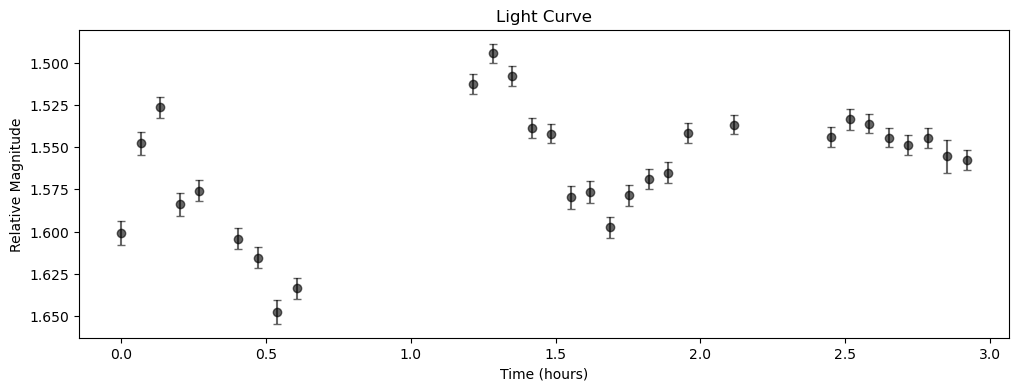

In [113]:
times, times_days, magnitudes, mag_errors = read_data(data_file1)

Best period: 0.0548 days (1.31 hours)
Peak power: 0.4958
Period uncertainty using FWHM: +/- 0.0296 days ( +/-0.71 hours)
Period: 1.31 +/- 0.71 hours
False alarm probability: 2.8764e-02


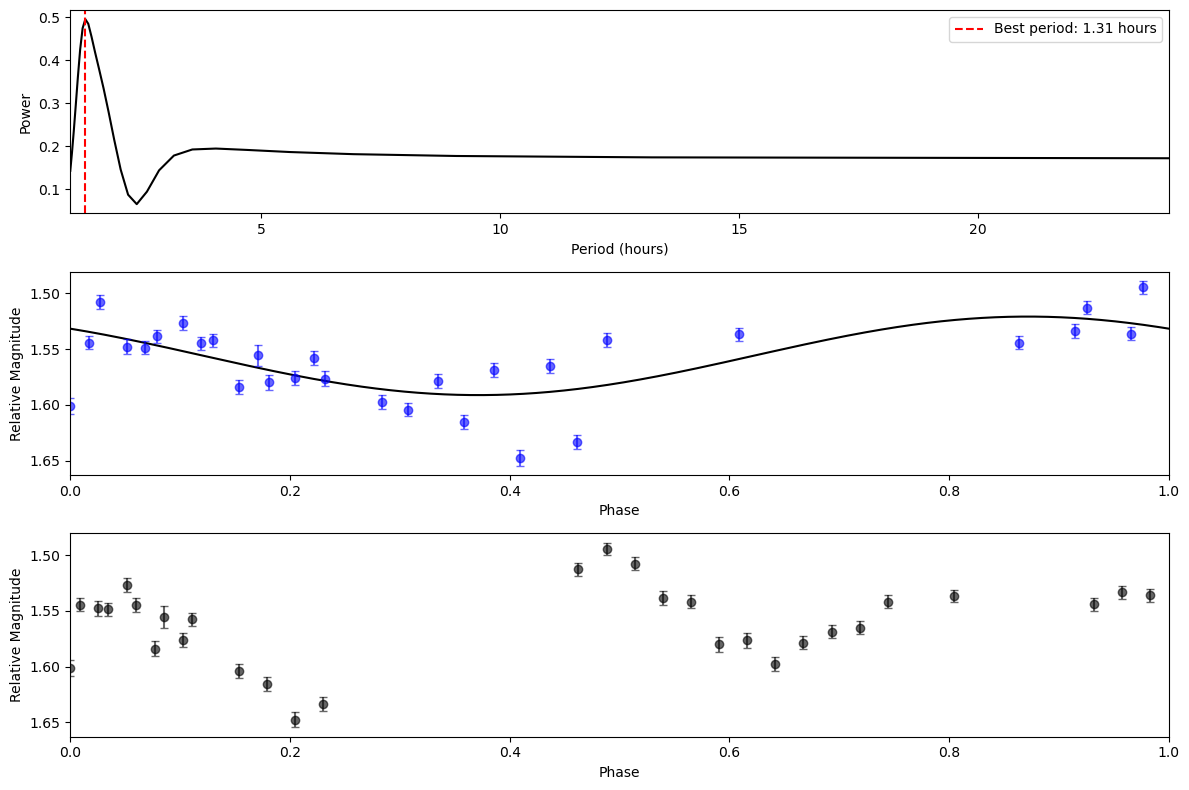

In [111]:
# Run with the first file data
lomb_scargle(times, times_days, magnitudes, mag_errors)

### Now, get the errors

Here, I get three options:

(1) Bootstrap

(2) Using the FWHM of the periodogram

(3) Monte Carlo 

Below, I've implemented a method for getting the uncertainty using the bootstrap method, but this appears to get a huge error, so above I've implemented some code for finding uncertainty based on the FWHM of the max peak. 

In [42]:
def bootstrap_period_uncertainty(times, mags, mag_errors, n_bootstrap=1000):
    """
    Estimate period uncertainty using bootstrap resampling
    """
    periods = []
    n_points = len(times)
    
    for i in range(n_bootstrap):
        indices = np.random.choice(n_points, size=n_points, replace=True)
        boot_times = times[indices]
        boot_mags = mags[indices]
        boot_errors = mag_errors[indices]
        
        # Run Lomb-Scargle
        ls_boot = LombScargle(boot_times, boot_mags, boot_errors)
        freq_boot, power_boot = ls_boot.autopower(minimum_frequency=1.0,
                                                   maximum_frequency=24.0,
                                                   samples_per_peak=10)
        
        best_freq = freq_boot[np.argmax(power_boot)]
        periods.append(1 / best_freq)
    
    boot_periods = np.array(periods)

    period_std = np.std(boot_periods)
    period_median = np.median(boot_periods)

    print(f"Median period: {period_median:.4f} days ({period_median*24:.2f} hours)")
    print(f"Period uncertainty using Bootstrap: +/-{period_std:.4f} days (+/-{period_std*24:.2f} hours)")
    print(f"Period: {period_median*24:.2f} +/- {period_std*24:.2f} hours")



In [43]:
bootstrap_period_uncertainty(times_days, magnitudes, mag_errors, n_bootstrap=1000)

Median period: 0.0561 days (1.35 hours)
Period uncertainty using Bootstrap: +/-0.0577 days (+/-1.38 hours)
Period: 1.35 +/- 1.38 hours


### Now, let's have a look at the second file

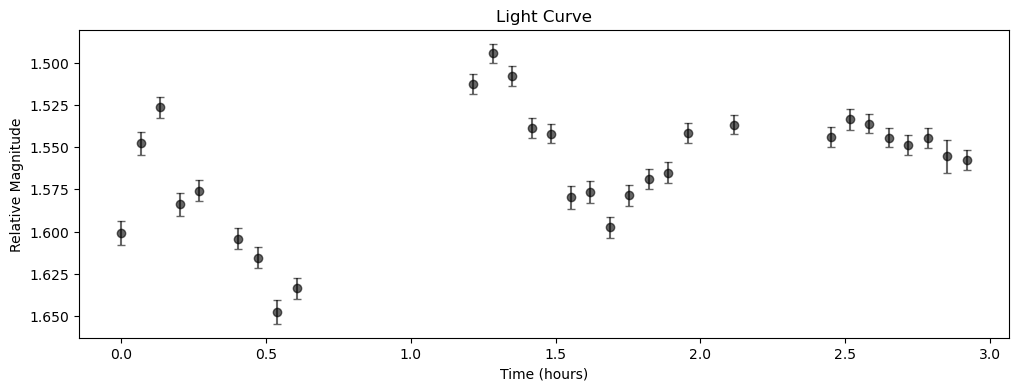

In [44]:
times, times_days, magnitudes, mag_errors = read_data(data_file2)

Best period: 0.0548 days (1.31 hours)
Peak power: 0.4958
Period uncertainty using FWHM: +/- 0.0296 days ( +/-0.71 hours)
Period: 1.31 +/- 0.71 hours
False alarm probability: 2.8764e-02


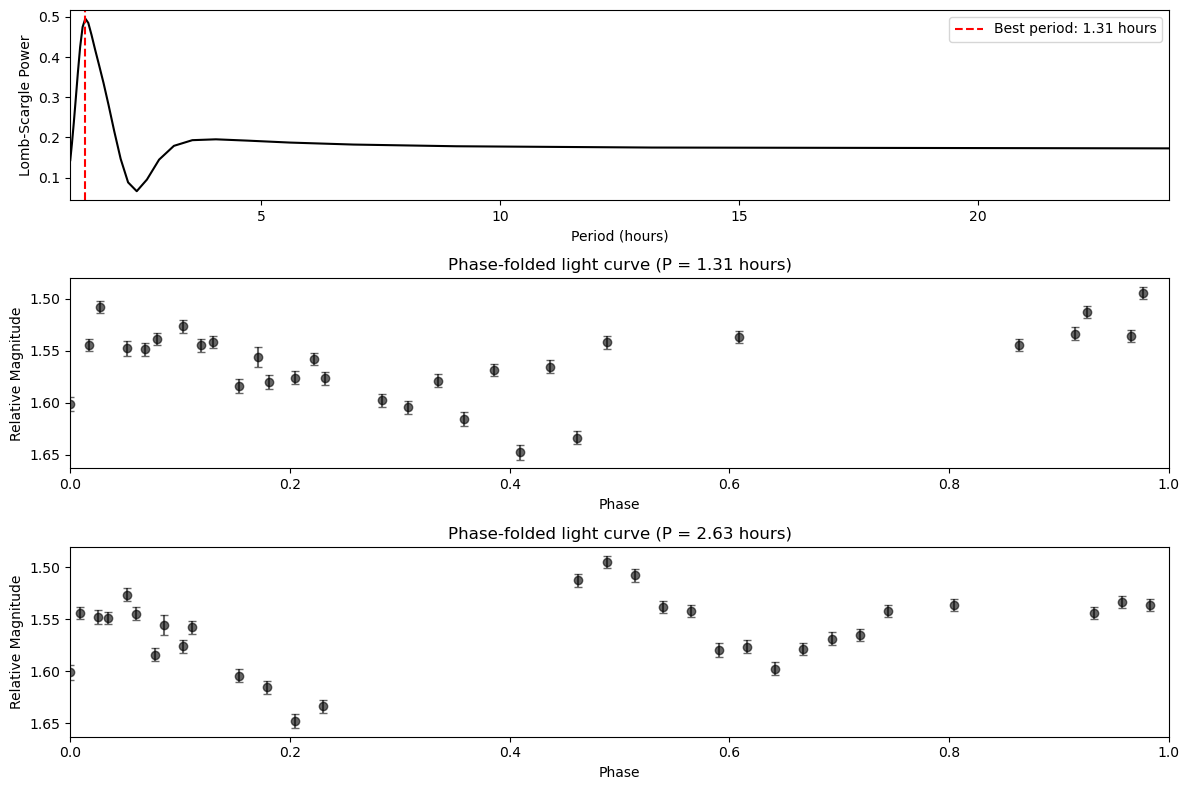

In [45]:
lomb_scargle(times, times_days, magnitudes, mag_errors)

In [48]:
bootstrap_period_uncertainty(times_days, magnitudes, mag_errors, n_bootstrap=1000)

Median period: 0.0561 days (1.35 hours)
Period uncertainty using Bootstrap: +/-0.0649 days (+/-1.56 hours)
Period: 1.35 +/- 1.56 hours


So, both files get a result fairly close to the literature period of 2.7097 ± 0.0001 according to our man Lorenzo [1], where we get to the literature value within a bit more than one sigma (HAHAHAH). 


[1] Franco, Lorenzo, Andrea Ferrero, Luis Martinez, Petr Pravec, and Stefano Padovan. ‘Binary Nature for the Asteroid 1052 Belgica’. Minor Planet Bulletin, 1 July 2013, 151–53.
